[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Target\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Target\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


=== Class Distribution ===
sentiment
negative    2134
positive    2028
neutral     1838
Name: count, dtype: int64

================ Naive Bayes Evaluation ================
Accuracy: 0.6400

Classification Report:
               precision    recall  f1-score   support

    negative       0.64      0.78      0.70       427
     neutral       0.66      0.46      0.54       368
    positive       0.63      0.66      0.65       405

    accuracy                           0.64      1200
   macro avg       0.64      0.63      0.63      1200
weighted avg       0.64      0.64      0.63      1200


================ Logistic Regression Evaluation ================
Accuracy: 0.6483

Classification Report:
               precision    recall  f1-score   support

    negative       0.69      0.70      0.69       427
     neutral       0.61      0.58      0.59       368
    positive       0.64      0.66      0.65       405

    accuracy                           0.65      1200
   macro avg       0.65  

C:\Users\Target\AppData\Local\Temp\ipykernel_22096\4127795145.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


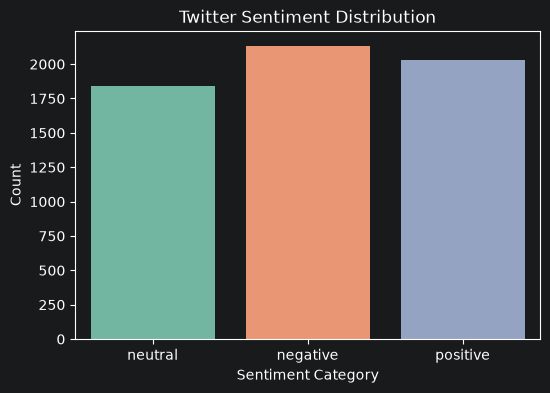

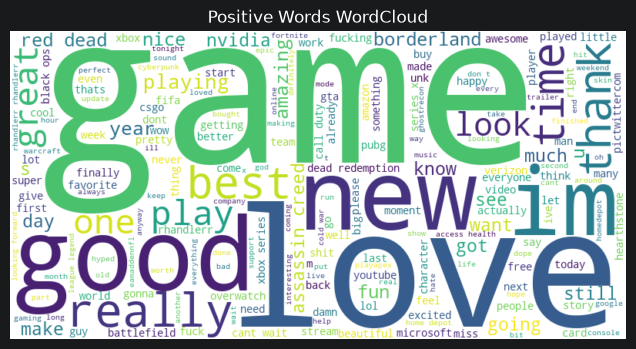


=== Error Analysis: Top 5 Misclassified Examples ===
                                                                                                                           Original_Text   Actual Predicted
                                                                                                                  Say the winning [UNK]. positive   neutral
                                                                      Netflix is the new Google. Products kill the way people love them. negative   neutral
                                                                               Verizon is having a bad Monday pic.twitter.com/ctSTk6qZt0 negative   neutral
Review: Microsoft Edge for Windows 10 finally offers a first-class browser | via @ windowscentral windowscentral.com / microsoft-edge... positive   neutral
         Nuttiest thing I have ever hit! through smoke double kill csgo... medal.tv / clips / 26795216... https: / / www.co / zXTjy4vtMj positive   neutral


In [5]:
# Task 4: Sentiment Analysis on Real Twitter Dataset
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# 1. Load Real Dataset
# Kaggle Twitter Dataset has 4 columns without headers: ID, Entity, Sentiment, Text
df = pd.read_csv('twitter_training.csv', header=None)
df.columns = ['id', 'entity', 'sentiment', 'text']

# Drop missing text rows & drop 'Irrelevant' to focus on 3 main classes (Positive, Negative, Neutral)
df = df.dropna(subset=['text'])
df = df[df['sentiment'] != 'Irrelevant']

# Standardize sentiment labels
df['sentiment'] = df['sentiment'].str.lower()

# Sample 6,000 rows for balanced and fast processing
df = df.sample(n=min(6000, len(df)), random_state=42).reset_index(drop=True)

print("=== Class Distribution ===")
print(df['sentiment'].value_counts())

# 2. Text Preprocessing Pipeline
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\w*\d\w*', '', text) # Remove numbers
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words] # Stopwords & Lemmatization
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Feature Extraction (TF-IDF Vectorizer)
# Note: TF-IDF converts raw text into numerical features while giving higher importance to informative words.
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['cleaned_text']).toarray()
y = df['sentiment']

# 4. Train / Test Split (80/20 Ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Model Training & Evaluation (2 Classifiers: Naive Bayes & Logistic Regression)
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n================ {name} Evaluation ================")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Visualizations (Sentiment Counts & Positive WordCloud)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Twitter Sentiment Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# WordCloud for Positive Sentiment
positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Words WordCloud')
plt.show()

# 7. Error Analysis (Top 5 Misclassified Examples)
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test)

test_indices = y_test.index
results_df = pd.DataFrame({
    'Original_Text': df.loc[test_indices, 'text'],
    'Actual': y_test,
    'Predicted': y_pred_best
})

misclassified = results_df[results_df['Actual'] != results_df['Predicted']].head(5)
print("\n=== Error Analysis: Top 5 Misclassified Examples ===")
print(misclassified.to_string(index=False))
